<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/Copy_of_Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1.Chuẩn bị vấn đề**

##**1.1.Khai báo thư viện**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules

##**1.2.Nạp dữ liệu**

In [27]:
df = pd.read_csv('/content/sample_data/Copy of Online Retail.csv')
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#**2.Data Cleaning**

##**2.1 Kiểm tra và xử lý Giá trị Bị thiếu (Missing Values)**

In [28]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


**Đánh giá**
- Với cột Description có 1454 dòng bị thiếu đây là các hàng bị hỏng, hủy hoặc điều chỉnh thủ công cần xóa các giá trị này để thực hiện phân tích
- Với cột CustomerID có 135080 dòng bị thiếu có nghĩa là các giao dịch này là của khách vãng lai hoặc các giao dịch mua tại quầy không định danh.
  - Với các dữ liệu bị thiếu này vẫn có thể sử dụng các giao dịch này để phân tích

In [29]:
#xóa các giá trị bị thiếu trong cột Description
df.dropna(subset=['Description'], inplace=True)


##**2.2. Loại bỏ Dữ liệu không hợp lệ**

In [30]:
filtered_data = df[df['UnitPrice'] == 0]
print(f"Số lượng giá trị cột UnitPrice = 0 : {len(filtered_data)}")

Số lượng giá trị cột UnitPrice = 0 : 1061


In [31]:
df = df[df['UnitPrice'] > 0]

**lọc và loại bỏ những dòng có giá sản phẩm (UnitPrice) bằng 0 hoặc nhỏ hơn 0.**

##**2.3. Xử lý Dữ liệu Trùng lặp**

In [32]:
print(f"Số dòng trùng lặp trước khi xóa: {df.duplicated().sum()}")

# Sửa lại ở đây: gán kết quả của hàm vào biến df
df = df.drop_duplicates()

print(f"Số dòng sau khi xóa trùng lặp: {len(df)}")

Số dòng trùng lặp trước khi xóa: 5263
Số dòng sau khi xóa trùng lặp: 534129


##**2.4. Chuẩn hóa Kiểu dữ liệu và Tạo Cột mới (Feature Engineering)**

In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Tạo cột TotalPrice (Tổng giá)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Tách thông tin từ cột InvoiceDate
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDayName'] = df['InvoiceDate'].dt.day_name()
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

- Chỉnh sửa Kiểu dữ liệu InvoiceDate: Cột InvoiceDate được chuyển đổi sang kiểu dữ liệu datetime để dễ dàng trích xuất thông tin dựa trên thời gian (như năm, tháng, ngày, giờ).

##**2.5. Kiểm tra lại Dữ liệu sau khi Làm sạch**

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 534129 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       534129 non-null  object        
 1   StockCode       534129 non-null  object        
 2   Description     534129 non-null  object        
 3   Quantity        534129 non-null  int64         
 4   InvoiceDate     534129 non-null  datetime64[ns]
 5   UnitPrice       534129 non-null  float64       
 6   CustomerID      401564 non-null  float64       
 7   Country         534129 non-null  object        
 8   TotalPrice      534129 non-null  float64       
 9   InvoiceYear     534129 non-null  int32         
 10  InvoiceMonth    534129 non-null  int32         
 11  InvoiceDayName  534129 non-null  object        
 12  InvoiceHour     534129 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(5)
memory usage: 50.9+ MB


In [35]:
num_rows = len(df)
print(f"Số dòng dữ liệu trong DataFrame là: {num_rows}")

Số dòng dữ liệu trong DataFrame là: 534129


**Kỹ thuật Đặc trưng (Feature Engineering)**

- Một số cột mới đã được tạo ra để làm phong phú thêm bộ dữ liệu và hỗ trợ cho việc phân tích sâu hơn:

- TotalPrice: Được tính bằng Quantity * UnitPrice, đại diện cho tổng doanh thu của mỗi dòng giao dịch.

- Các Thành phần Thời gian: Các cột như InvoiceYear, InvoiceMonth, InvoiceDay, InvoiceHour. Các đặc trưng này rất hữu ích để phân tích xu hướng bán hàng theo thời gian (ví dụ: xu hướng theo tháng, theo ngày trong tuần, hoặc các giờ cao điểm).

**Tóm tắt Bộ dữ liệu sau khi Làm sạch & Kỹ thuật Đặc trưng**
- Sau khi trải qua tất cả các bước làm sạch và kỹ thuật đặc trưng, bộ dữ liệu hiện đã sẵn sàng cho các phân tích sâu hơn.

- Tổng số dòng cuối cùng: 534129

- Tổng số cột cuối cùng: 13 (8 cột ban đầu cộng với 5 cột mới được tạo ra)

- Thống kê Mô tả: Các thống kê mô tả cung cấp một cái nhìn tổng quan về sự phân bổ giá trị trong các cột dạng số như Quantity, UnitPrice, và TotalPrice.

#**3.EDA-Phân tích dữ liệu**
***Chúng ta đang bán hàng như thế nào?***

##**3.1.Phân tích Đơn biến (Univariate Analysis)**

**Trước tiên, hãy cùng xem hoạt động kinh doanh của chúng ta theo dòng thời gian. Khi nào là thời điểm chúng ta bán hàng hiệu quả nhất?**

###**3.1.1.Phân tích Doanh số Hàng tháng (Xu hướng Bán hàng Tháng):**

**Xu hướng doanh thu hàng tháng cho chúng ta biết điều gì? Tháng nào đỉnh điểm, tháng nào trũng? Chúng ta có thể chuẩn bị gì cho những mùa cao điểm?**

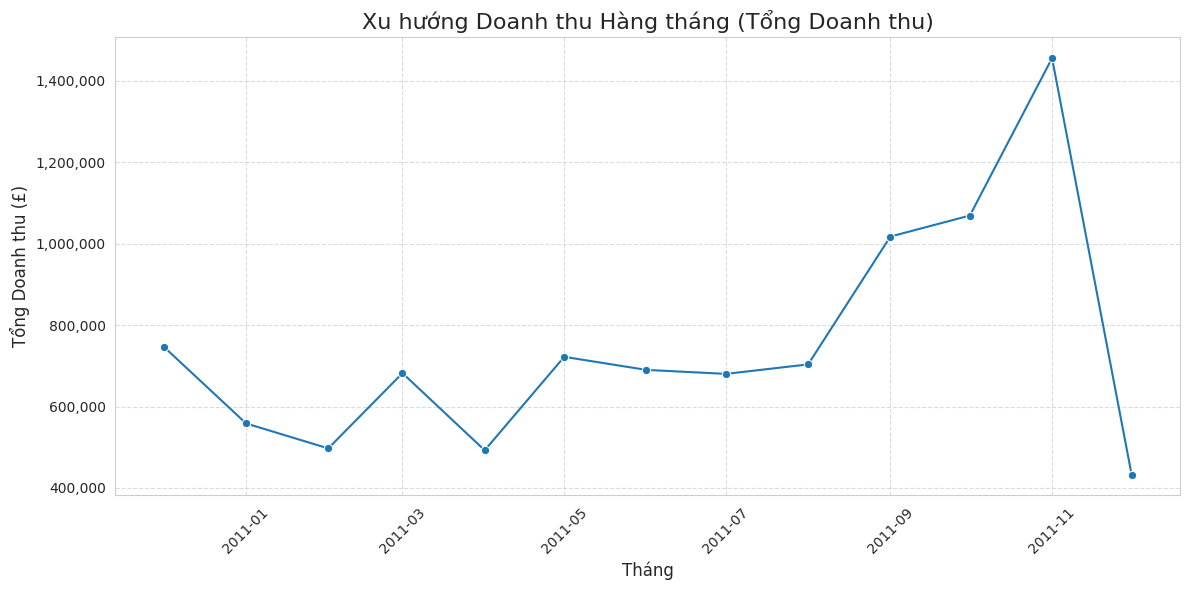

In [36]:
sns.set_style("whitegrid")
monthly_sales = df.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str) + '-01')

# Thiết lập kích thước cho biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ đường
sns.lineplot(x='YearMonth', y='TotalPrice', data=monthly_sales, marker='o')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Xu hướng Doanh thu Hàng tháng (Tổng Doanh thu)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

# Định dạng số trên trục y để hiển thị số cụ thể
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Tinh chỉnh thêm cho biểu đồ
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Đánh giá:**
- Doanh thu đạt đỉnh cao nhất vào tháng 11 năm 2011 với hơn 1,5 triệu, trong khi tháng 2 cùng năm ghi nhận mức doanh thu thấp nhất là 523,084.

- Mô hình theo mùa: phần lớn doanh thu tập trung vào quý cuối cùng của năm (đặc biệt là gần cuối năm). Sau đỉnh điểm vào tháng 11, doanh thu tháng 12 sụt giảm mạnh (có thể do dữ liệu của tháng này không đầy đủ). Xu hướng thông thường là doanh thu sẽ giảm vào tháng 1 sau khi đạt đỉnh trong kỳ nghỉ lễ.

###**3.1.2.Phân tích Doanh số theo Ngày trong Tuần**

**Doanh số theo ngày trong tuần nói lên điều gì? Khách hàng có thích mua sắm vào cuối tuần hơn không?**

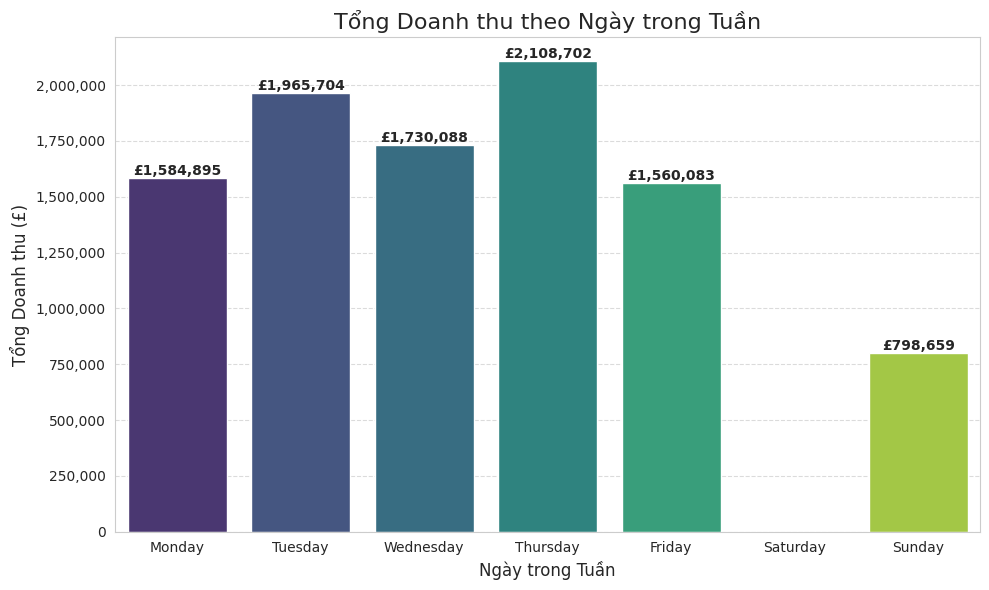

In [39]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = df.groupby('InvoiceDayName')['TotalPrice'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='InvoiceDayName', y='TotalPrice', data=sales_by_day, palette='viridis', hue='InvoiceDayName', legend=False)

plt.title('Tổng Doanh thu theo Ngày trong Tuần', fontsize=16)
plt.xlabel('Ngày trong Tuần', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

# Định dạng số trên trục y để hiển thị số cụ thể
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Thêm nhãn giá trị lên trên mỗi cột
for i, v in enumerate(sales_by_day['TotalPrice']):
    ax.text(i, v, f'£{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**

- Nhịp điệu mua sắm: Khách hàng có xu hướng dành thời gian mua sắm nhiều hơn vào các ngày trong tuần.

- Thứ Năm là điểm đáng chú ý: Sự gia tăng doanh thu vào Thứ Năm có thể do:

  - Khách hàng mua sắm chuẩn bị cho cuối tuần.

  - Các chiến dịch khuyến mãi thường được triển khai vào thời điểm này.

**Câu hỏi: Tại sao doanh thu vào Chủ Nhật lại thấp như vậy?**

  - Nếu doanh nghiệp vẫn mở cửa, có thể nhu cầu mua sắm vào Chủ Nhật của khách hàng thấp một cách tự nhiên. Điều này có thể do thói quen của họ (chỉ mua sắm hoặc làm việc vào các ngày trong tuần) hoặc do ngành hàng này thường không có hoạt động sôi nổi vào cuối tuần.

###**3.1.3.Phân tích Doanh số theo Giờ**

**Theo từng giờ trong ngày, khung giờ vàng để bán hàng là khi nào? Tại sao doanh thu lại có đỉnh điểm rõ rệt vào các khung giờ cao điểm?**

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='InvoiceHour', y='TotalPrice', data=sales_by_hour, marker='o', color='purple')

# Đặt tiêu đề và nhãn cho biểu đồ
plt.title('Tổng Doanh thu theo Giờ trong Ngày', fontsize=16)
plt.xlabel('Giờ trong Ngày', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

# Đặt nhãn cho trục giờ một cách chính xác để hiển thị tất cả các giờ
plt.xticks(range(int(df['InvoiceHour'].min()), int(df['InvoiceHour'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Những phát hiện chính:**
- Thời gian tương đối cao điểm: Doanh thu duy trì ở mức cao từ 10 giờ sáng đến 15 giờ chiều, với một đỉnh nhỏ vào khoảng 15 giờ.

- Thời gian thấp điểm: Doanh thu giảm mạnh sau 15 giờ chiều và gần như bằng 0 sau 19 giờ tối.

- Giờ mở cửa và đóng cửa: Dựa vào biểu đồ, có thể thấy doanh nghiệp hoạt động từ khoảng 6 giờ sáng đến 20 giờ tối

**Câu hỏi: Tại sao doanh thu lại có hai đỉnh điểm rõ rệt vào 10 giờ sáng và 12 giờ trưa?**
- Hai đỉnh này có thể phản ánh thói quen mua sắm của khách hàng. 2 khung giờ này trùng với giờ nghỉ trưa, khi nhiều người có thời gian để mua sắm hoặc ăn uống.

###**3.1.4.Phân tích số lượng đơn hàng theo Quốc gia**

**Không chỉ về thời gian, chúng ta cũng cần biết: Chúng ta đang bán hàng cho ai và ở đâu? Phân bố đơn hàng theo quốc gia cho thấy thị trường trọng điểm nào đang đóng góp nhiều nhất?**

In [ ]:
import plotly.express as px
# --- 2. Làm sạch và chuẩn bị dữ liệu ---
# Chuyển đổi InvoiceDate sang kiểu datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Loại bỏ các dòng không có CustomerID vì chúng thường là các giao dịch không hoàn chỉnh
df.dropna(subset=['CustomerID'], inplace=True)

# --- 3. Phân tích số lượng đơn hàng theo Quốc gia ---
# Đếm số lượng hóa đơn (đơn hàng) duy nhất cho mỗi quốc gia
country_orders = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
country_orders.rename(columns={'InvoiceNo': 'NumberOfOrders'}, inplace=True)

# Sắp xếp các quốc gia theo số lượng đơn hàng giảm dần
country_orders_sorted = country_orders.sort_values(by='NumberOfOrders', ascending=False)

# Lấy top 20 quốc gia để biểu đồ dễ nhìn hơn
top_20_countries = country_orders_sorted.head(20)

# --- 4. Trực quan hóa bằng biểu đồ cột ---
fig = px.bar(top_20_countries,
             x='Country',
             y='NumberOfOrders',
             title='Phân tích Số lượng Đơn hàng theo Quốc gia (Top 20)',
             labels={'Country': 'Quốc gia', 'NumberOfOrders': 'Số lượng đơn hàng'},
             color='NumberOfOrders',
             color_continuous_scale=px.colors.sequential.Plasma,
             text_auto=True) # Hiển thị giá trị trên mỗi cột

# Tùy chỉnh giao diện biểu đồ cho đẹp hơn
fig.update_layout(
    xaxis_title="Quốc gia",
    yaxis_title="Số lượng đơn hàng",
    title_x=0.5, # Căn giữa tiêu đề
    xaxis={'categoryorder':'total descending'} # Sắp xếp các cột theo giá trị giảm dần
)

fig.show()

# Hiển thị 5 quốc gia có nhiều đơn hàng nhất dưới dạng bảng
print("Top 5 quốc gia có nhiều đơn hàng nhất:")
print(country_orders_sorted.head())

**Điểm mạnh (Insight rút ra):**
- Thị trường Anh (United Kingdom) thống trị tuyệt đối: Đây là điểm nổi bật nhất. Với 16,649 đơn hàng, thị trường Anh không chỉ là thị trường lớn nhất mà còn lớn hơn tất cả các thị trường khác cộng lại rất nhiều lần.



**Sau khi đã hiểu về 'KHI NÀO' và 'Ở ĐÂU', một câu hỏi quan trọng hơn cần được trả lời: 'CÁI GÌ' đang tạo ra doanh thu và 'CÁI GÌ' đang gây ra vấn đề?**

##**3.2.Phân tích Đa biến (Multivariate Analysis)**

**Sản phẩm nào là người hùng, và sản phẩm nào là điểm yếu?**

###**3.2.1.Top 10 Sản phẩm theo Số lượng**

**Top sản phẩm bán chạy theo số lượng? Đâu là những mặt hàng phổ thông, có sức hút lớn.**



In [ ]:
top_selling_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("--- 10 Sản phẩm bán chạy nhất dựa trên Số lượng ---")
print(top_selling_quantity)
print("\n")

# Trực quan hóa Top 10 sản phẩm bán chạy nhất dựa trên Số lượng
plt.figure(figsize=(12, 7))
sns.barplot(x=top_selling_quantity.values, y=top_selling_quantity.index, palette='Blues_r', hue=top_selling_quantity.index, legend=False)
plt.title('10 Sản phẩm bán chạy nhất dựa trên Tổng số lượng đã bán', fontsize=16)
plt.xlabel('Tổng số lượng đã bán', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.tight_layout()
plt.show()



 **Biểu đồ này cho thấy rõ ràng các sản phẩm có số lượng bán ra cao nhất, giúp xác định đâu là những mặt hàng chủ lực của doanh nghiệp.**

- Sản phẩm Phổ biến nhất: Sản phẩm "WORLD WAR 2 GLIDERS ASSTD DESIGNS" đứng đầu bảng xếp hạng là sản phẩm có số lượng bán ra nhiều nhất. Điều này cho thấy sự phổ biến rất cao của nó trong giới tiêu dùng.
- Sự Thống trị của Sản phẩm Thủ công và Gia dụng: Năm sản phẩm hàng đầu bị chiếm ưu thế bởi các mặt hàng liên quan đến đồ thủ công và trang trí nhà cửa



###**3.2.2.Sản phẩm Bán chạy nhất theo Doanh thu (Revenue/TotalPrice)**

**Nhưng liệu những sản phẩm bán chạy có phải là những sản phẩm mang lại doanh thu cao nhất không? Hay có những sản phẩm 'quý tộc' khác, dù bán ít nhưng giá trị mỗi đơn lại rất lớn?"**

In [ ]:
top_selling_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("--- 10 Sản phẩm bán chạy nhất dựa trên Doanh thu ---")
print(top_selling_revenue)
print("\n")

# Trực quan hóa Top 10 sản phẩm bán chạy nhất dựa trên Doanh thu
plt.figure(figsize=(12, 7))
sns.barplot(x=top_selling_revenue.values, y=top_selling_revenue.index, palette='Greens_d', hue=top_selling_revenue.index, legend=False)
plt.title('10 Sản phẩm bán chạy nhất dựa trên Tổng Doanh thu', fontsize=16)
plt.xlabel('Tổng Doanh thu (£)', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**
- Sản phẩm "REGENCY CAKESTAND 3 TIER " là sản phẩm mang lại doanh thu cao nhất. Điều này khẳng định đây là sản phẩm chủ lực, vừa được yêu thích rộng rãi vừa có giá trị cao.

- Sự Thống trị của Đồ trang trí & Gia dụng: Tương tự như phân tích theo số lượng, danh sách này tiếp tục cho thấy sức mạnh của các mặt hàng trang trí nhà cửa và quà tặng. Đây rõ ràng là danh mục sản phẩm cốt lõi của doanh nghiệp.

###**3.2.2.Phân tích các đơn hàng bị hủy/trả lại**

**Bên cạnh những thành tích, chúng ta cũng cần nhìn vào sự thật: Đâu là những sản phẩm đang gây thất thoát doanh thu nhiều nhất do bị hủy/trả lại? Hiểu được lý do đằng sau sẽ giúp chúng ta cải thiện chất lượng sản phẩm, mô tả, hoặc dịch vụ**

In [ ]:
# --- 2. Lọc các đơn hàng bị hủy/trả lại ---
cancelled_orders = df[df['InvoiceNo'].astype(str).str.startswith('C')]

# --- 3. Tìm top sản phẩm bị trả lại nhiều nhất ---
top_cancelled_products = cancelled_orders['Description'].value_counts().reset_index()
top_cancelled_products.columns = ['ProductDescription', 'CancellationCount']

# =======================================================
# == BẠN THÊM CODE LỌC VÀO NGAY ĐÂY ==
# =======================================================
# 1. Tạo danh sách các mục cần loại bỏ
items_to_remove = ['POSTAGE', 'Discount', 'Manual']

# 2. Lọc ra khỏi bảng top_cancelled_products
top_cancelled_products = top_cancelled_products[~top_cancelled_products['ProductDescription'].isin(items_to_remove)]
# =======================================================

# Lấy top 10 sản phẩm sau khi đã lọc
top_10 = top_cancelled_products.head(10)

# In kết quả dạng bảng
print("--- Top 10 sản phẩm (đã lọc) bị trả lại/hủy nhiều nhất ---")
print(top_10)

# --- 4. Trực quan hóa kết quả ---
fig = px.bar(top_10,
             x='CancellationCount',
             y='ProductDescription',
             orientation='h', # Biểu đồ cột ngang
             title='Top 10 Sản phẩm bị Hủy/Trả lại nhiều nhất (Đã lọc)',
             labels={'ProductDescription': 'Mô tả sản phẩm', 'CancellationCount': 'Số lần bị hủy/trả lại'},
             text='CancellationCount')

# Sắp xếp các cột và tùy chỉnh giao diện
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)
fig.show()

**Dựa trên biểu đồ:**


- Sản phẩm "REGENCY CAKESTAND 3 TIER"  có doanh thu cao nhất nhưng đồng thời cũng là sản phẩm bị hủy/trả lại nhiều nhất. Điều này cho thấy đây là một sản phẩm rất phổ biến và bán chạy, nhưng có thể gặp vấn đề về chất lượng, mô tả sản phẩm không chính xác, hoặc hư hỏng trong quá trình vận chuyển.

- Sản phẩm có rủi ro: Sản phẩm "JUMBO BAG RED RETROSPOT" cũng nằm trong top 10 của cả hai biểu đồ (top bán chạy về số lượng, top bị hủy về số lần). Đây cũng là một sản phẩm phổ biến nhưng có tỷ lệ trả lại đáng kể, cho thấy có thể có vấn đề với nó.-



**Câu hỏi: lý do khách quan vì sao các sản phẩm này lại có tỉ lệ trả hàng cao?**
-  **Mua hàng theo Cảm hứng & Hối hận Ngay lập tức**. Khách hàng thấy chúng dễ thương trên kệ và mua ngay. Tuy nhiên, chỉ vài phút sau, khi đang xếp hàng thanh toán hoặc ra về, họ bắt đầu suy nghĩ lại.
- **Lỗi Sản xuất & Hư hại có sẵn**. Khách hàng có thể phát hiện ra một vết nứt nhỏ, vết rỗ men, hoặc hình in bị lệch khi kiểm tra kỹ tại cửa hàng. Họ sẽ bỏ sản phẩm đó lại và chọn sản phẩm khác
- **Chính sách Trả hàng Dễ dàng**. Cửa hàng có thể có chính sách trả hàng rất thoải mái. Điều này vô tình khuyến khích hành vi mua về dùng thử, không ưng thì trả.

##**3.3.Phân tích RFM & Phân cụm**
***Chúng ta đã nắm rõ về sản phẩm và thời gian. Nhưng để phát triển bền vững, chìa khóa nằm ở chính khách hàng. Vậy, làm thế nào để chúng ta thực sự hiểu và phân loại được khách hàng của mình?***

**RFM Analysis giúp phân nhóm khách hàng dựa trên mức độ tương tác và giá trị mang lại, từ đó doanh nghiệp:**

- Hiểu ai là khách hàng trung thành,

- Ai đang có nguy cơ rời bỏ,

- Và ai là khách hàng tiềm năng cần chăm sóc thêm.

**Tính 3 chỉ số cho từng khách hàng:**
- Recency (R): Ngày giao dịch gần nhất → tính số ngày kể từ lần mua gần nhất đến hiện tại.
→ Càng nhỏ càng tốt (mới mua gần đây).

- Frequency (F): Số lượng giao dịch (đơn hàng) trong một khoảng thời gian.
→ Càng lớn càng tốt.

- Monetary (M): Tổng tiền chi tiêu.
→ Càng lớn càng tốt.

In [ ]:
# 1. Xác định Ngày Tham chiếu (snapshot_date)
# Đây là mốc "hiện tại" để tính toán Recency.
# Chúng ta lấy ngày giao dịch cuối cùng trong bộ dữ liệu, sau đó cộng thêm 1 ngày.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Ngày tham chiếu cho phân tích RFM: {snapshot_date}\n")

# 2. Tính toán các giá trị R, F, M cho mỗi CustomerID
# Sử dụng groupby() trên CustomerID và agg() để tính R, F, M
rfm_df = df.groupby('CustomerID').agg(
    # Recency: Số ngày kể từ lần mua hàng cuối cùng
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),

    # Frequency: Số lượng giao dịch (hóa đơn) duy nhất
    Frequency=('InvoiceNo', 'nunique'),

    # Monetary: Tổng số tiền đã chi tiêu
    Monetary=('TotalPrice', 'sum')
).reset_index() # reset_index() chuyển CustomerID từ chỉ mục thành cột

print("--- Dữ liệu RFM của Khách hàng (5 Dòng đầu tiên) ---")
print(rfm_df.head())
print("\n")

print("--- Thống kê mô tả của RFM ---")
print(rfm_df.describe())
print("\n")

# 3. Trực quan hóa Phân phối của RFM (Histogram)
# Giúp chúng ta hiểu sự phân bổ của khách hàng trên mỗi tiêu chí RFM
plt.figure(figsize=(18, 6)) # Kích thước lớn hơn cho 3 biểu đồ con

# Biểu đồ con cho Recency
plt.subplot(1, 3, 1) # 1 hàng, 3 cột, vị trí thứ 1
sns.histplot(rfm_df['Recency'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối của Recency', fontsize=14)
plt.xlabel('Số ngày kể từ lần mua cuối', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Biểu đồ con cho Frequency
plt.subplot(1, 3, 2) # 1 hàng, 3 cột, vị trí thứ 2
sns.histplot(rfm_df['Frequency'], bins=50, kde=True, color='lightcoral')
plt.title('Phân phối của Frequency', fontsize=14)
plt.xlabel('Số lượng giao dịch', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Biểu đồ con cho Monetary
plt.subplot(1, 3, 3) # 1 hàng, 3 cột, vị trí thứ 3
sns.histplot(rfm_df['Monetary'], bins=50, kde=True, color='lightgreen')
plt.title('Phân phối của Monetary', fontsize=14)
plt.xlabel('Tổng chi tiêu (£)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

plt.tight_layout() # Tự động điều chỉnh layout để không bị chồng chéo
plt.show()



**1. Phân phối của Recency**

**Nhận xét:**
- Phần lớn khách hàng có Recency nhỏ (0–50 ngày).
→ Nghĩa là đa số khách hàng vừa mới mua gần đây.

- Một số ít khách hàng có Recency cao (200–350 ngày).
→ Đây là nhóm lâu không quay lại, có nguy cơ rời bỏ.

**Kết luận:**
- Tập khách hàng có tỷ lệ khách hàng hoạt động gần đây cao, đây là dấu hiệu tích cực.
- Tuy nhiên, cũng cần tái kích hoạt nhóm Recency cao (gửi ưu đãi, email…).

**2. Phân phối của Frequency**

**Nhận xét:**

- Đa số khách hàng chỉ mua 1–5 lần.

- Rất ít khách hàng mua hơn 50 lần (đuôi bên phải kéo dài).

**Kết luận:**

- Phần lớn là khách hàng mua ít / không thường xuyên.

- Cần chiến lược chăm sóc và khuyến khích mua lại (loyalty, voucher...).

**3. Phân phối của Monetary**

**Nhận xét:**

- Rất nhiều khách hàng chi tiêu ít tiền, nằm ở vùng thấp (gần 0).

- Một vài khách hàng chi tiêu cực lớn (đuôi dài sang phải).

**Kết luận:**

- Doanh thu chủ yếu đến từ một nhóm nhỏ khách hàng chi tiêu cao (hiệu ứng Pareto 80/20).

- Nên tập trung chăm sóc đặc biệt nhóm này vì họ đóng góp phần lớn doanh thu.

###**3.3.1 Phân tích Giỏ hàng (Market Basket Analysis)**

**Trước khi đi sâu vào từng cá nhân, hãy khám phá hành vi mua sắm của họ: Những sản phẩm nào thường được mua cùng nhau?**

In [ ]:

# Loại bỏ các mục không phải sản phẩm để kết quả phân tích chính xác hơn
non_product_items = ['POSTAGE', 'DOTCOM POSTAGE', 'CARRIAGE', 'Manual', 'BANK CHARGES']
df_mba = df[~df['Description'].isin(non_product_items)].copy()
print(f"Đã loại bỏ các mục không phải sản phẩm.")

# Tạo định dạng 'giỏ hàng' (basket) mà thuật toán Apriori yêu cầu
# Hàng là InvoiceNo, cột là Description, giá trị là 1 nếu sản phẩm được mua, ngược lại là 0
basket = (df_mba.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Hàm để mã hóa số lượng thành dạng nhị phân (0 hoặc 1)
def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_units)
print("Chuẩn bị dữ liệu giỏ hàng hoàn tất.")


# --- PHẦN 2: CHẠY THUẬT TOÁN APRIORI VÀ TẠO LUẬT KẾT HỢP ---

# Tìm các nhóm sản phẩm phổ biến (frequent itemsets)
# min_support = 0.02 nghĩa là nhóm sản phẩm phải xuất hiện trong ít nhất 2% tổng số giao dịch
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)
print("\nTìm kiếm các nhóm sản phẩm phổ biến hoàn tất.")

# Tạo các luật kết hợp từ các nhóm sản phẩm phổ biến
# metric="lift", min_threshold=1: Chỉ lấy các luật có mối quan hệ tích cực
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Sắp xếp các luật theo 'lift' và 'confidence' để xem những luật mạnh nhất
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print("\nTạo các luật kết hợp hoàn tất.")
print("\n--- 10 Luật Kết hợp Hàng đầu (Mạnh nhất) ---")
# Hiển thị kết quả với các cột quan trọng
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
warnings.filterwarnings('ignore', category=DeprecationWarning)

# --- PHẦN 3: TRỰC QUAN HÓA CÁC LUẬT KẾT HỢP QUAN TRỌNG NHẤT ---

# Chuẩn bị dữ liệu cho biểu đồ
top_10_rules = rules.head(10).copy()
top_10_rules['rule'] = top_10_rules.apply(lambda row: f"{list(row['antecedents'])[0]} -> {list(row['consequents'])[0]}", axis=1)

# Thiết lập phong cách và vẽ biểu đồ
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
sns.barplot(x='lift', y='rule', data=top_10_rules, palette='viridis')
plt.title('Top 10 Luật Kết hợp có Giá trị Lift Cao nhất', fontsize=16)
plt.xlabel('Giá trị Lift (Độ mạnh của mối quan hệ)', fontsize=12)
plt.ylabel('Luật Kết hợp (Nếu mua A -> thì mua B)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**
- Xu hướng mua hàng rõ rệt: Khách hàng có xu hướng mua các sản phẩm này cùng nhau một cách có chủ đích.
- Đặc điểm chung của các cặp sản phẩm: Hầu hết là các sản phẩm bổ sung, thay thế hoặc cùng thuộc một bộ sưu tập. Cụ thể:

  - Sản phẩm cùng loại, khác mẫu mã/màu sắc: Tách trà Regency (màu hồng, xanh lá, họa tiết hoa hồng), Đồng hồ báo thức Bakelike (đỏ & xanh), Bộ đồ trang trí Giáng sinh (Vintage & 50's).

  - Sản phẩm cùng chủ đề, khác kiểu dáng: Tấm quỳ làm vườn (Kiểu "Cup of Tea" & "Keep Calm").

**Gợi ý Hành động 💡**

Phát hiện này cung cấp những gợi ý rất cụ thể và dễ thực hiện để thúc đẩy doanh số:

- Tạo Combo Khuyến mãi: Xây dựng các gói sản phẩm như "Mua bộ 3 tách trà được giảm giá" hoặc "Mua 2 tặng 1" để khuyến khích khách hàng mua trọn bộ.

- Gợi ý Sản phẩm (Cross-selling): Trên trang web, khi khách hàng xem sản phẩm tách trà màu Hồng, hãy hiển thị gợi ý "Thường được mua cùng" với màu Xanh và màu Hoa hồng ngay bên cạnh.

- Chiến dịch Marketing: Triển khai các chiến dịch email hoặc quảng cáo nhắm vào những khách hàng đã mua một màu, khuyến khích họ "hoàn thành bộ sưu tập" của mình.

- Trưng bày Sản phẩm: Tại cửa hàng vật lý, hãy đặt các sản phẩm này cạnh nhau để khách hàng dễ dàng nhìn thấy và lựa chọn cả bộ.

###**3.3.2.Kmeans**

**Bây giờ, ta sử dụng mô hình RFM để phân loại khách hàng một cách khoa học:**

####**3.3.2.1.CHUẨN HÓA DỮ LIỆU RFM**

In [ ]:

# K-Means rất nhạy cảm với sự khác biệt về thang đo của dữ liệu (ví dụ: Monetary có thể lớn hơn Recency rất nhiều).
# StandardScaler sẽ đưa tất cả các biến về cùng một thang đo.
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']]),
                          columns=['Recency', 'Frequency', 'Monetary'])

print("--- Dữ liệu RFM sau khi chuẩn hóa (5 dòng đầu) ---")
print(rfm_scaled.head())
print("-" * 50)

####**3.3.2.2.TÌM SỐ CỤM TỐI ƯU (K) BẰNG PHƯƠNG PHÁP ELBOW**

In [ ]:

# Phương pháp này giúp xác định số lượng cụm (K) tốt nhất cho dữ liệu.
# "Khuỷu tay" (Elbow) trên biểu đồ là điểm K tối ưu.

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # n_init=10 để tránh kết quả xấu do khởi tạo ngẫu nhiên
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Số lượng Cụm (K)")
plt.ylabel('Inertia (Tổng bình phương khoảng cách)')
plt.title('Phương pháp Elbow để tìm K tối ưu')
plt.grid(True)
plt.show()


**Sau khi chuẩn hóa dữ liệu (3.3.2.1) và tìm ra số cụm tối ưu (3.3.2.2), chúng ta sẽ phân nhóm khách hàng (3.3.2.3)**

####**3.3.2.3.ÁP DỤNG K-MEANS VÀ GÁN NHÃN CỤM**

In [ ]:
# Dựa vào biểu đồ Elbow, chúng ta chọn số cụm K tối ưu (ví dụ: K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Gán nhãn cụm cho mỗi khách hàng vào DataFrame RFM ban đầu
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"\n--- Phân khách hàng vào {optimal_k} cụm hoàn tất ---")
print(rfm_df.head())
print("-" * 50)

####**3.3.2.4.PHÂN TÍCH VÀ DIỄN GIẢI CÁC CỤM**

**Mỗi nhóm khách hàng này có đặc điểm gì? Ai là 'VIP', ai là 'Khách hàng tiềm năng', và ai đang 'ngủ quên'? Mỗi nhóm cần một chiến lược chăm sóc khác nhau.**

In [ ]:
cluster_analysis = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# 2. Thêm cột 'Interpretation' (Diễn giải) thủ công
# LƯU Ý: Thứ tự của các diễn giải này phải tương ứng với Cluster 0, 1, 2, 3...
# Bạn cần xem kết quả từ bước 1 để xác định đúng đặc điểm cho mỗi cụm.
interpretations = [
    "🟡 Average customers - khách hàng trung bình, mua sắm gần đây vừa phải, tần suất và chi tiêu không cao.",
    "🔴 At risk / Churned - khách hàng có nguy cơ rời bỏ, đã lâu không hoạt động, tần suất và chi tiêu thấp.",
    "🟢 Champions / VIPs - khách hàng VIP, mua rất gần đây, rất thường xuyên và chi tiêu cực lớn.",
    "🔵 Loyal Customers - khách hàng trung thành, hoạt động tích cực, mua hàng thường xuyên và chi tiêu mạnh."
]

# Gán danh sách diễn giải vào cột mới
cluster_analysis['Interpretation'] = interpretations

# (Tùy chọn) Đổi tên cột để thêm các mũi tên cho giống với hình ảnh
cluster_analysis.rename(columns={
    'Recency': 'Recency ↓',
    'Frequency': 'Frequency ↑',
    'Monetary': 'Monetary ↑'
}, inplace=True)


# 3. Hiển thị bảng kết quả cuối cùng
# Trong Jupyter Notebook/Colab, chỉ cần gọi tên DataFrame là nó sẽ hiển thị đẹp
cluster_analysis

####**3.3.2.5.TRỰC QUAN HÓA CÁC CỤM BẰNG PCA**

**Hình ảnh trực quan hóa bằng PCA sẽ cho chúng ta thấy một cách rõ ràng các nhóm khách hàng có thực sự tách biệt và khác biệt hay không.**

In [ ]:
# Giảm chiều dữ liệu từ 3D (R, F, M) xuống 2D để vẽ biểu đồ
# Giả định rfm_scaled và rfm_df['Cluster'] đã có từ các bước trước
# --- BẮT ĐẦU CODE VẼ BIỂU ĐỒ ĐÃ CẬP NHẬT ---

# 1. Giữ nguyên phần tính toán PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled)

# 2. Định nghĩa tên và màu sắc cho từng cụm
cluster_names = {
    0: 'Khách hàng Trung bình',   # Tương ứng với màu 'gold'
    1: 'Khách hàng Rủi ro/Rời bỏ', # Tương ứng với màu 'red'
    2: 'Khách hàng VIP/Champions',# Tương ứng với màu 'green'
    3: 'Khách hàng Trung thành'    # Tương ứng với màu 'blue'
}
custom_palette = {
    0: 'gold',
    1: 'red',
    2: 'green',
    3: 'blue'
}

# 3. Tính toán số lượng và phần trăm
cluster_counts = rfm_df['Cluster'].value_counts()
cluster_percentages = rfm_df['Cluster'].value_counts(normalize=True) * 100

# 4. Tạo nhãn mới cho phần chú thích (legend)
# Sắp xếp theo thứ tự cluster (0, 1, 2, 3) để đảm bảo khớp với màu sắc
legend_labels = []
for cluster_id in sorted(cluster_counts.index):
    name = cluster_names[cluster_id]
    count = cluster_counts[cluster_id]
    percent = cluster_percentages[cluster_id]
    # Tạo chuỗi văn bản mới, ví dụ: "Khách hàng VIP: 500 KH (25.00%)"
    label = f"{name}: {count} KH ({percent:.2f}%)"
    legend_labels.append(label)

# 5. Vẽ biểu đồ
plt.figure(figsize=(12, 8)) # Tăng kích thước để có không gian cho chú thích
ax = sns.scatterplot(x=pca_components[:, 0],
                     y=pca_components[:, 1],
                     hue=rfm_df['Cluster'],
                     palette=custom_palette,
                     s=100,
                     alpha=0.8)

# 6. Cập nhật chú thích với thông tin mới
# Lấy các handles (chấm màu) từ legend cũ và gán nhãn mới mà chúng ta đã tạo
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Phân khúc khách hàng', fontsize=10)

# 7. Hoàn thiện biểu đồ
plt.title('Các Phân khúc Khách hàng (Trực quan hóa bằng PCA)', fontsize=16)
plt.xlabel('Thành phần chính 1 (PCA Component 1)', fontsize=12)
plt.ylabel('Thành phần chính 2 (PCA Component 2)', fontsize=12)
plt.grid(True)
plt.tight_layout() # Tự động điều chỉnh cho vừa vặn
plt.show()

# --- KẾT THÚC CODE VẼ BIỂU ĐỒ ĐÃ CẬP NHẬT ---

 **Đánh Giá Tình Hình Hiện Tại**

**Nhìn chung:** Cơ sở khách hàng đang ở trạng thái cảnh báo, với một tỷ lệ rất lớn khách hàng sắp rời bỏ và một nhóm khách hàng trung thành/VIP quá mỏng.

- **Điểm BÁO ĐỘNG ĐỎ:** "Khách hàng Rủi ro/Rời bỏ" chiếm tới 24.87%.

  - Đây là một con số cực kỳ lớn, cho thấy gần 1/4 tổng số khách hàng đang không hài lòng, ít giao dịch hoặc sắp ngừng mua hàng.

- **Điểm YẾU:** Nhóm khách hàng giá trị cao quá ít.

  - Khách hàng VIP/Champions chỉ có 0.14% (6 người): Nhóm này là "con gà đẻ trứng vàng" nhưng lại cực kỳ ít.

  - Khách hàng Trung thành chỉ có 2.52%: Tỷ lệ này cho thấy khả năng giữ chân khách hàng (Customer Retention) đang rất kém.

- **Điểm CẦN CẢI THIỆN:** Nhóm "Khách hàng Trung bình" chiếm đa số (72.48%).

  - Đây là nhóm tiềm năng nhất để "nuôi dưỡng" và nâng cấp lên các phân khúc cao hơn. Hiện tại, họ đang ở trạng thái trung lập và dễ dàng chuyển sang nhóm "Rủi ro" nếu không được chăm sóc tốt.

#**4.Kết luận**
**1. Dựa vào biểu đồ xu hướng doanh thu hàng tháng, ta có thể thực hiện một số hành động sau:**
- Phát triển chiến lược marketing: Dựa vào các tháng doanh thu cao, có thể phát triển các chiến dịch marketing hiệu quả hơn, tập trung vào các sản phẩm bán chạy hoặc các sự kiện đã tạo ra doanh thu tốt.

- Quản lý kho hàng: Đảm bảo đủ hàng trong các tháng cao điểm để tránh tình trạng hết hàng và mất doanh thu. Ngược lại, tránh tồn kho quá nhiều trong các tháng thấp điểm.

**2. Dựa vào doanh thu theo Ngày trong Tuần ta có thể thực hiện kế hoạch kinh doanh như sau**

- **Tối ưu hóa các ngày cao điểm (Thứ Ba & Thứ Năm)**
  - Tăng cường sản phẩm: Tập trung cung cấp các sản phẩm hoặc dịch vụ bán chạy nhất vào hai ngày này để tối đa hóa lợi nhuận.

  - Chiến dịch khuyến mãi: Tổ chức các chương trình khuyến mãi nhỏ, đặc biệt (ví dụ: "Deal hot ngày Thứ Năm") để thu hút thêm khách hàng và duy trì đà tăng trưởng.

- **Kích thích doanh thu vào các ngày thấp điểm (Cuối tuần)**
  - Phát triển các chiến dịch đặc biệt cho cuối tuần để kích thích mua sắm. Ví dụ: "Ưu đãi cuối tuần", "Mua 1 tặng 1 vào Chủ Nhật".

**3.Người quản lý cần phải tối ưu hóa doanh thu trong các khung giờ**
- chuẩn bị sẵn sàng các sản phẩm bán chạy, hoặc chạy các chương trình khuyến mãi ngắn hạn ("giờ vàng mua sắm") vào các khung giờ này để tận dụng tối đa lượng khách hàng.
- Đối với các khung giờ thấp điểm có thể áp dụng các chiến lược marketing nhắm vào các khung giờ này, ví dụ như khuyến mãi giờ muộn hoặc dịch vụ giao hàng cho những người không có thời gian mua sắm sớm hơn.

**4.Rủi ro và Cơ hội dựa trên số lượng đơn hàng giữa các quốc gia:**

- **Rủi ro phụ thuộc:** Sự phụ thuộc quá lớn vào một thị trường duy nhất (Anh) là một rủi ro lớn. Bất kỳ sự biến động nào về kinh tế, chính trị, hay cạnh tranh tại Anh đều sẽ ảnh hưởng nghiêm trọng đến toàn bộ doanh nghiệp.

- **Cơ hội tăng trưởng:** Tiềm năng phát triển rất lớn ở các thị trường quốc tế, đặc biệt là Đức và Pháp. Nếu có thể đẩy mạnh marketing và bán hàng để tăng trưởng ở các thị trường này, doanh nghiệp sẽ đa dạng hóa được rủi ro và mở rộng quy mô.

**5.Các Giải Pháp Thực Tế Để Giảm Thiểu Hủy/Trả Lại**

- **Đào Tạo Nhân Viên Trở Thành "Chuyên Gia Tư Vấn"**. Nhân viên là cầu nối quan trọng để quản lý kỳ vọng. Nhân viên phải hiểu rõ điểm mạnh, điểm yếu của từng sản phẩm.
- **Điều Chỉnh Chính Sách Bán Hàng & Tiếp Thị**. Xem xét lại chính sách trả hàng: Thay vì "Trả hàng miễn phí không cần lý do", có thể chuyển sang chính sách "Đổi hàng trong vòng 14 ngày" cho các sản phẩm không bị lỗi.
- **Thu Thập & Phân Tích Phản Hồi**. Hỏi lý do trả hàng: Khi có khách trả hàng, hãy thiết kế một mẫu đơn giản để ghi lại lý do.

**6.Gợi Ý Hành Động Chiến Lược dựa theo xu hướng khách hàng mua các sản phẩm cùng nhau**
- **Trưng bày & Sắp xếp cửa hàng**. Điều này khuyến khích khách hàng so sánh và mua nhiều mẫu hơn.
- **Tiếp thị & Khuyến mại**. Ưu đãi Combo: Đưa ra các ưu đãi nhỏ khi mua combo. Ví dụ: "Mua 2 tách trà Regency khác màu, được giảm 10%" hoặc "Mua combo 2 chiếc đồng hồ Bakelike, tặng kèm pin".

**7. Phân khúc khách hàng**
- Nhóm VIP (Xanh lá) là mỏ vàng: Mặc dù chỉ có 6 khách hàng, họ cực kỳ khác biệt so với phần còn lại. Đây là nhóm cần có chính sách chăm sóc đặc biệt, cá nhân hóa tối đa để giữ chân và khai thác thêm giá trị.

- Nhóm Trung thành (Xanh dương) là nền tảng: Đây là những khách hàng có giá trị cao và ổn định. Chiến lược phù hợp là nuôi dưỡng, xây dựng mối quan hệ để dần biến họ thành VIP.

- Thách thức lớn nhất nằm ở nhóm Trung bình (Vàng) và Rủi ro (Đỏ):
+ Hai nhóm này chiếm tới 95% tổng số khách hàng.

  + Trên biểu đồ, chúng nằm rất gần nhau và có phần chồng chéo. Điều này cho thấy hành vi của họ khá tương đồng, và ranh giới giữa một khách hàng "trung bình" và một khách hàng "sắp rời bỏ" là rất mong manh.

  + Đây là khu vực cần sự can thiệp marketing khéo léo nhất: Làm sao để giữ chân nhóm Rủi ro mà không tốn quá nhiều chi phí? Làm sao để thúc đẩy nhóm Trung bình mua nhiều hơn?
